In [1]:
from datetime import datetime
import pandas as pd
import networkx as nx
from visualize_ean import plot_ean, draw_ean
from visualize_ean_plotly import plot_ean_plotly, draw_ean_plotly, show_ean
from build_ean import build_ean, add_headway_arcs, propagate, enrich_trip_data_with_boundaries
import headway_integration as hi
import numpy as np
from collections import defaultdict
import sys
from pathlib import Path as path
import report as rp

project_root = path(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from tools.schematic_map.routing import (build_route,get_signal_nodes_on_route,)
from infra_data.scenarios import load_network_csv, load_headways, get_scenario
from tools.RailML2trip_data.reassign_trip_id import reassign_trip_ids_by_departure


# Import infrastructure and timetable, clean and prepare data

In [2]:
nodesDf = load_network_csv("nodes.csv", "node_id")
edgesDf = load_network_csv("edges.csv", "edge_id")
scenario = get_scenario()
#edgesDf["length"] = (edgesDf["node_to"].map(nodesDf["pk_rel"])- edgesDf["node_from"].map(nodesDf["pk_rel"])).abs()
#trip_data = np.load(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\plottingRailML\230215 FBS Fpl 2026-NB-1443983-3.npy", allow_pickle=True).item()
trip_data = np.load(rf"C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau\tools\RailML2trip_data\trip_data_{scenario}.npy", allow_pickle=True).item()
headway_dict = load_headways()
selected_trips_sorted = np.array(list(trip_data.keys()))

In [3]:
trip_data = {
    train_id: [
        (station, arr_dt, dep_dt, True)
        for station, arr_dt, dep_dt in stops
    ]
    for train_id, stops in trip_data.items()
}

In [4]:
trip_data, ordered_old_ids=reassign_trip_ids_by_departure(trip_data)

In [5]:
routing_results = {}

for stop_col in ["stop_slow", "stop_fast"]:

    stops = nodesDf.index[(nodesDf[stop_col] == 1) & (nodesDf["y"] == 0)].tolist()

    for start, end in zip(stops[:-1], stops[1:]):

        routing_results[(start, end)] = build_route(nodesDf, edgesDf, start, end)
        routing_results[(end, start)] = build_route(nodesDf, edgesDf, end, start)

In [6]:
routes = {}
for trip_id, trip in trip_data.items():
    start, end = trip[0][0], trip[-1][0]
    routes[trip_id] = build_route(nodesDf, edgesDf, start, end)

In [7]:
#add side nodes to trip data

from copy import deepcopy

def add_side_nodes_to_trip_data(trip_data, nodesDf):
    """
    Return a copy of trip_data where terminal nodes are replaced by their
    '_side' counterpart, but only for trains running from Merano to Malles
    (i.e. decreasing pk_rel).

    A stop 'X' is replaced by 'X_side' only if:
      - 'X_side' exists in nodesDf, and
      - the train direction is Merano -> Malles.
    """
    trip_data_sides = deepcopy(trip_data)

    available_nodes = set(nodesDf.index)

    for train_id, stops in trip_data_sides.items():

        # Need at least two stops to infer direction
        if len(stops) < 2:
            continue

        pk0 = nodesDf.loc[stops[0][0], "pk_rel"]
        pk1 = nodesDf.loc[stops[1][0], "pk_rel"]

        # Merano -> Malles corresponds to decreasing pk_rel
        merano_to_malles = pk1 > pk0

        if not merano_to_malles:
            continue

        for i, (node, arr, dep, is_stop) in enumerate(stops):

            side_node = f"{node}_side"

            if side_node in available_nodes:
                stops[i] = (side_node, arr, dep, True)

    return trip_data_sides

In [8]:
trip_data_sides = add_side_nodes_to_trip_data(trip_data, nodesDf)

In [9]:
IG = hi.build_infra_graph(edgesDf)
chains, boundary_nodes = hi.extract_chains(IG, nodesDf)

print("Chains:", chains)
print("Boundary Nodes:", boundary_nodes)
trip_data_enriched = enrich_trip_data_with_boundaries(trip_data_sides, routes, nodesDf, boundary_nodes)

Chains: {('Dev_LASA_01', 'Dev_ORIS_01'): ['Dev_LASA_01', 'Pa_I_LASA_31_side', 'LASA_side', 'Pa_I_LASA_32_side', 'Dev_LASA_02_side', 'Pr_I_LASA_52_side', 'Pa_I_LASA_62_side', 'PL29_side', 'Pr_I_LASA_72_side', 'Pa_E_LASA_82_side', 'Pr_E_LASA_02_side', 'HD_701_01_side', 'SblLasa46915_side', 'HD_701_03_side', 'Pr_E_ORIS_01_side', 'Dev_ORIS_01'], ('Dev_ORIS_01', 'Dev_SPON_01'): ['Dev_ORIS_01', 'Pr_I_ORIS_71', 'PL30', 'Pa_ORIS_31', 'ORIS', 'Pa_ORIS_32', 'Pr_E_ORIS_02', 'HD_702_02', 'Pr_E_SPON_01', 'Pa_E_SPON_81', 'Pr_I_SPON_71', 'PL31', 'Pr_I_SPON_51', 'Pa_I_SPON_61', 'Dev_SPON_01'], ('Dev_LAC_01', 'Dev_LAC_02'): ['Dev_LAC_01', 'Pa_I_LAC_31_side', 'LAC_side', 'Pa_I_LAC_32_side', 'Dev_LAC_02'], ('Dev_LAC_02', 'Dev_COLD_01'): ['Dev_LAC_02', 'Pr_I_LAC_52', 'Pa_E_LAC_62', 'PL19', 'Pr_I_LAC_72', 'Pr_E_LAC_02', 'SblLac31026', 'HD_501_02', 'Pr_E_COLD_01', 'Pr_I_COLD_91', 'PL20', 'Pa_COLD_31', 'Dev_COLD_01'], ('Dev_STA_02', 'Dev_PL13_01'): ['Dev_STA_02', 'Pr_I_STA_52', 'Pa_E_STA_62', 'PL12', 'Pr_I_S

In [10]:
# Remove opposite-direction headways on double-track chains
headway_dict = deepcopy(headway_dict)

# --------------------------------------------------
# Step 1: Count how many infrastructure edges occupy
# each elementary pk interval
# --------------------------------------------------

pk_values = sorted(nodesDf["pk_rel"].unique())

interval_count = defaultdict(int)

for _, edge in edgesDf.iterrows():

    pk1 = nodesDf.loc[edge["node_from"], "pk_rel"]
    pk2 = nodesDf.loc[edge["node_to"], "pk_rel"]

    a, b = sorted((pk1, pk2))

    for left, right in zip(pk_values[:-1], pk_values[1:]):
        if left >= a and right <= b:
            interval_count[(left, right)] += 1


# --------------------------------------------------
# Step 2: Determine whether each chain is entirely
# on double track
# --------------------------------------------------

double_track_chains = set()

for chain_key, chain_nodes in chains.items():

    is_double = True

    for n1, n2 in zip(chain_nodes[:-1], chain_nodes[1:]):

        pk1 = nodesDf.loc[n1, "pk_rel"]
        pk2 = nodesDf.loc[n2, "pk_rel"]

        a, b = sorted((pk1, pk2))

        for left, right in zip(pk_values[:-1], pk_values[1:]):
            if left >= a and right <= b:
                if interval_count[(left, right)] < 2:
                    is_double = False
                    break

        if not is_double:
            break

    if is_double:
        double_track_chains.add(chain_key)


# --------------------------------------------------
# Step 3: Remove opposite-direction headways
# on double-track chains
# --------------------------------------------------

for key in list(headway_dict):

    chain_key, cat1, cat2 = key

    if chain_key in double_track_chains:

        opposite = (
            ("up" in cat1 and "down" in cat2)
            or
            ("down" in cat1 and "up" in cat2)
        )

        if opposite:
            del headway_dict[key]

# Build EAN, add headway constraints

In [11]:
constraints, skipped = hi.assemble_headway_constraints(trip_data_sides, trip_data_enriched, routes, nodesDf, chains, headway_dict)


G_scheduled = build_ean(trip_data_enriched)
G_scheduled = add_headway_arcs(G_scheduled, constraints)
assert nx.is_directed_acyclic_graph(G_scheduled), "graph must stay a DAG"

# Stochastic Perturbation

In [ ]:
node_perturbations, edge_perturbations = hi.generate_perturbation_scenarios(G_scheduled,
    n_scenarios=100,
    entry_delay_mean=1*60,
    entry_delay_std=3*60,
    running_delay_mean=2*60,
    running_delay_std=1*60,
    perturbation_probability = 0.05,
    seed=42,
)

## Propagation

In [19]:
realized_graphs = []

for node_p, edge_p in zip(node_perturbations,edge_perturbations,):

    G_realized = propagate(G_scheduled,edge_perturbations=edge_p,node_perturbations=node_p,)
    realized_graphs.append(G_realized)

## Visualization

### Plotly

In [ ]:
fig, ax = plot_ean_plotly(G_scheduled,nodesDf,edgesDf,title=f"Scenario {scenario}: Scheduled vs Perturbed Timetable",)

for G_realized in realized_graphs[:2]:

    draw_ean_plotly(G_realized,nodesDf,ax,alpha=0.5,linewidth_scale=0.8,)


show_ean(fig,filename=f"ean_visualization{scenario}.html",auto_open=True,)

EAN visualization written to: C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau\ean_simulation\ean_visualization3c.html


WindowsPath('ean_visualization3c.html')

# Punctuality indicators 

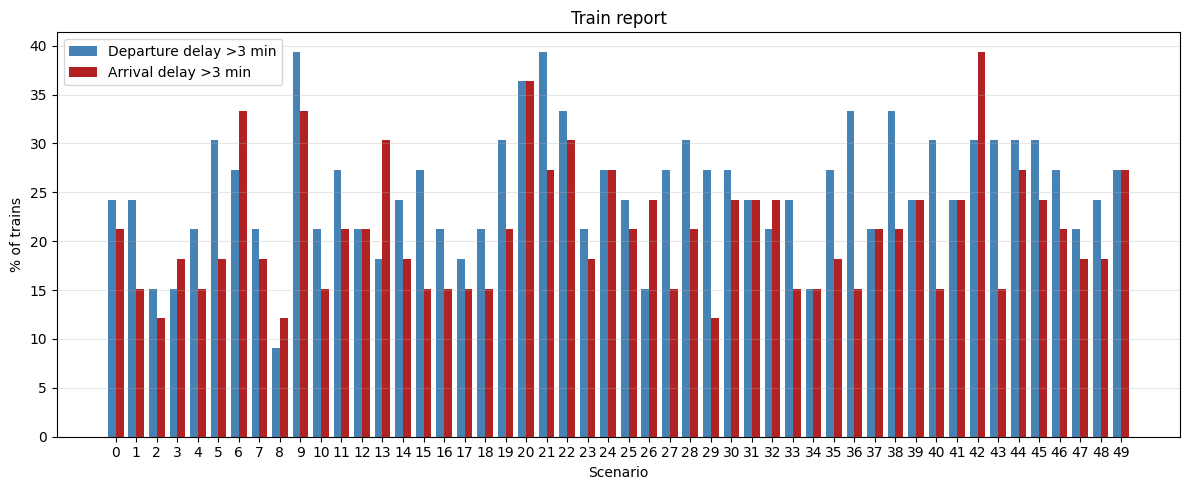

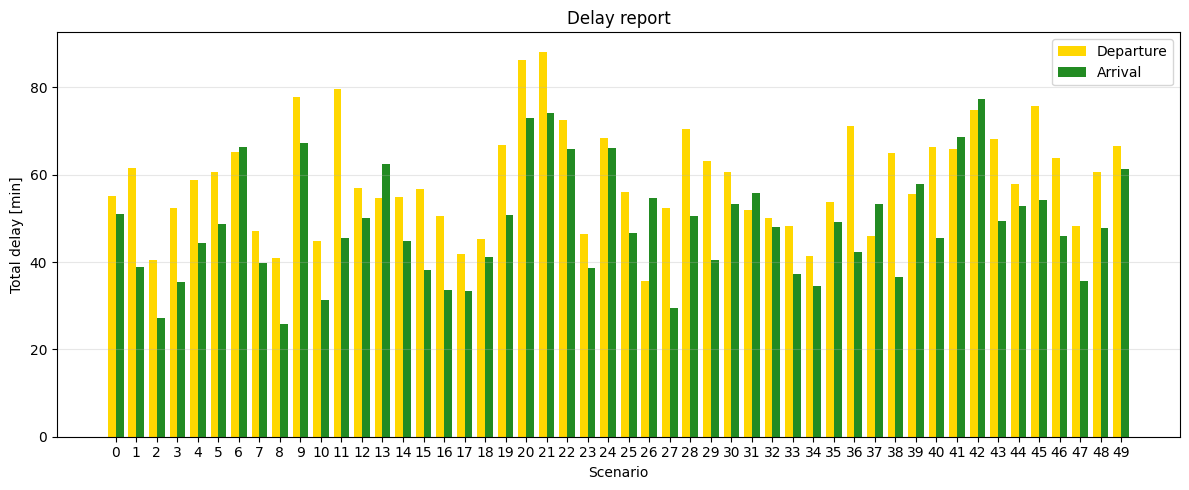

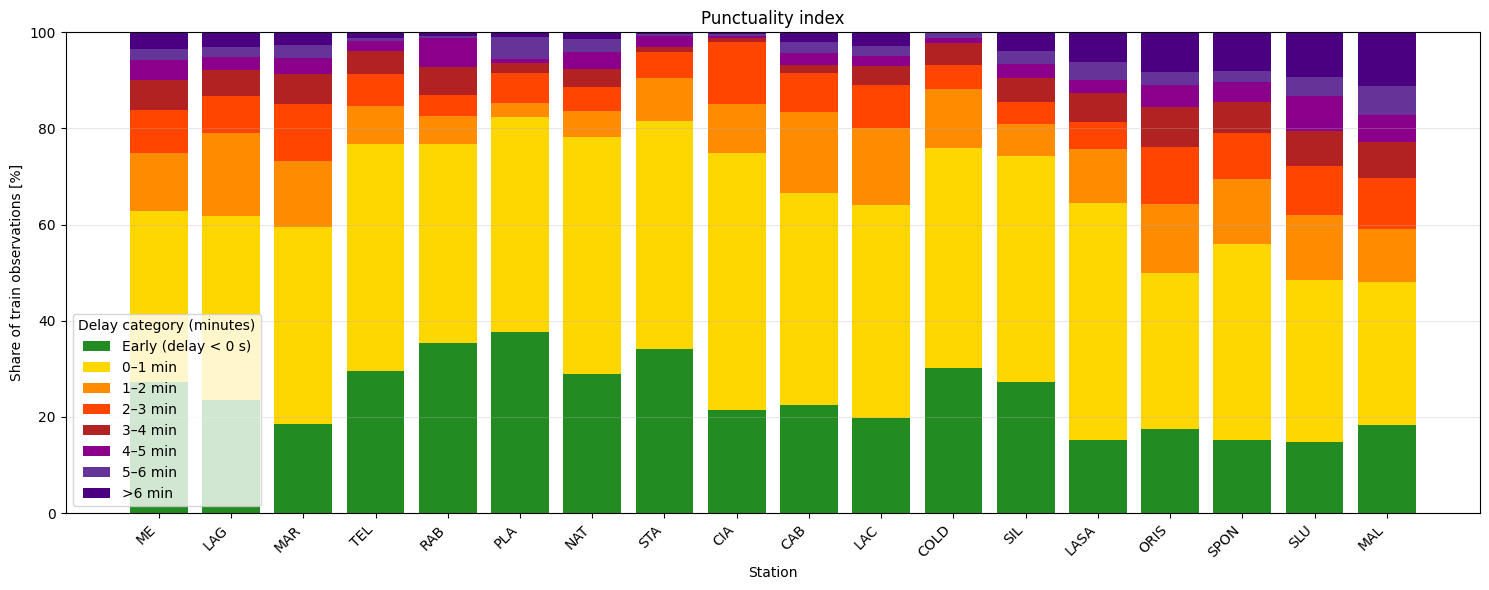

In [15]:
stats = rp.extract_statistics(realized_graphs)

rp.plot_train_report(stats)
rp.plot_delay_report(stats)
rp.plot_punctuality_index(stats)

In [16]:
stop

NameError: name 'stop' is not defined

# Manual Perturbation

## Propagation

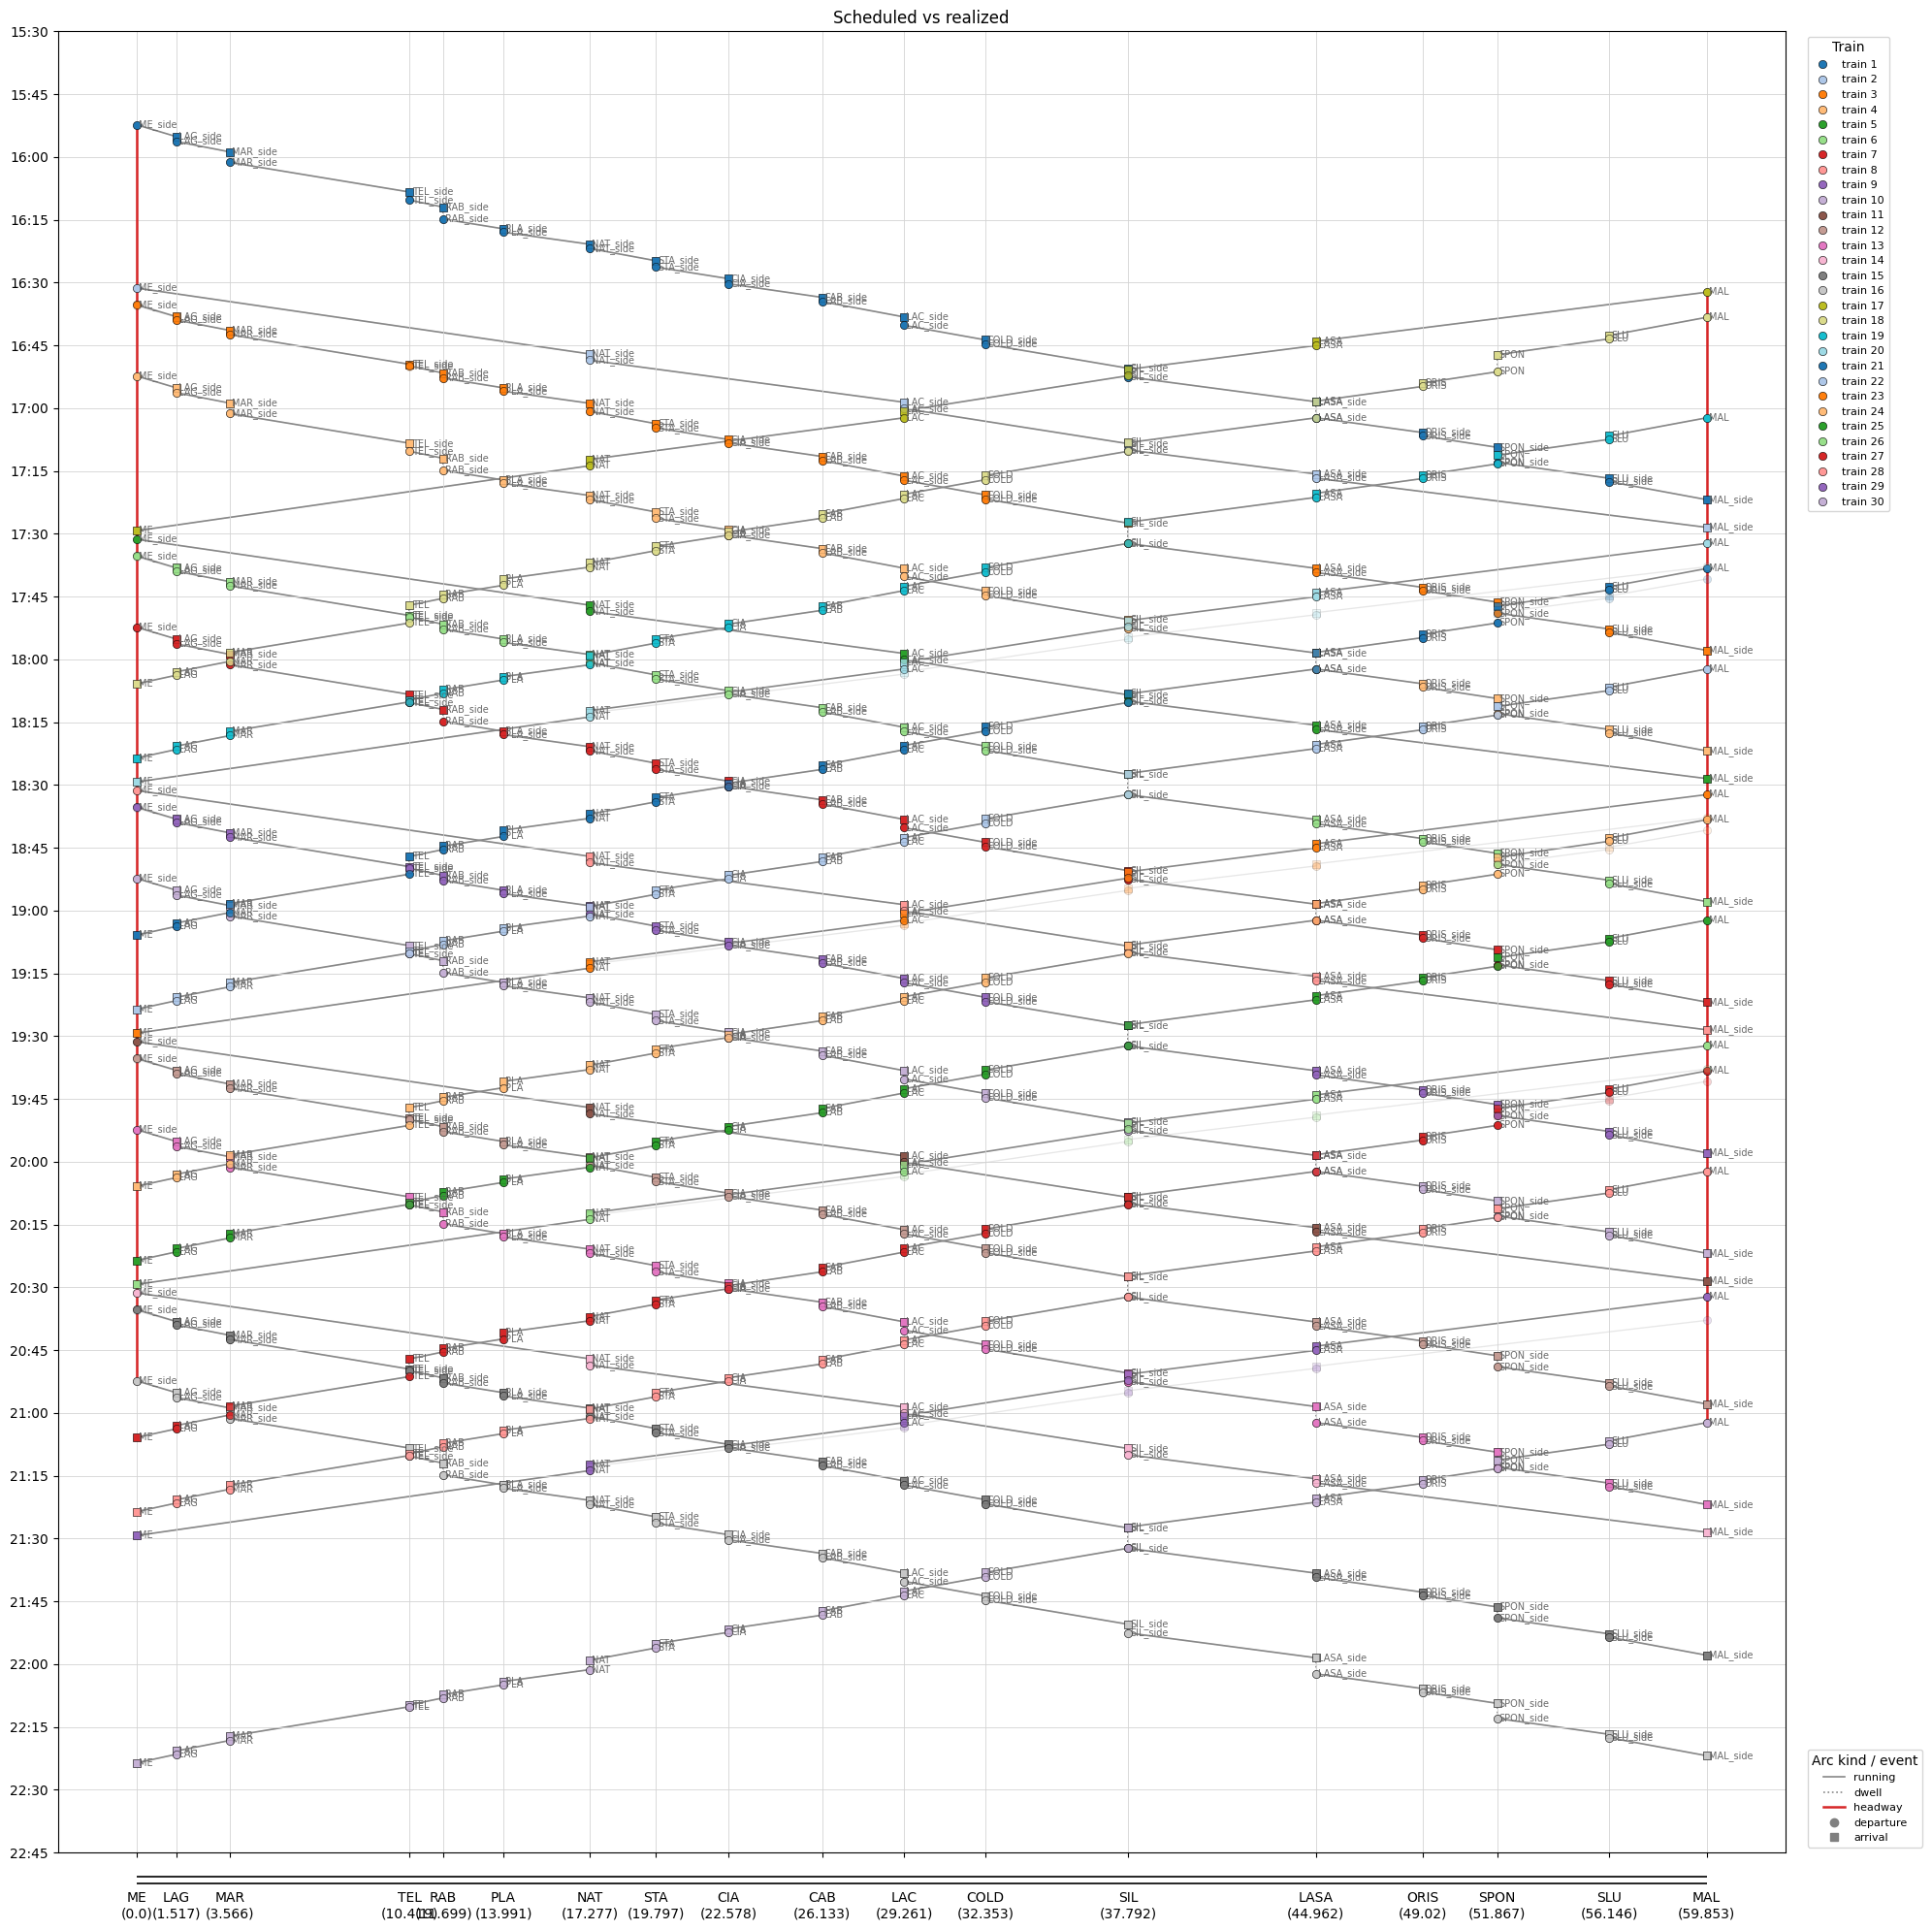

In [ ]:
#inject delays manually
running_edges = [(u, v) for u, v, data in G_scheduled.edges(data=True) if data["kind"] == "running"]
edge = running_edges[0]  

#perturbations = [{},{edge: 60},{edge: 120},{edge: 300}]
perturbations = [{edge:0}]


realized_graphs = []

for p in perturbations:

    G_realized = propagate(G_scheduled, p)

    realized_graphs.append(G_realized)


fig, ax = plot_ean(G_scheduled, nodesDf, edgesDf, title="Scheduled vs realized")

for G_realized in realized_graphs:
    draw_ean(G_realized,nodesDf,ax,alpha=0.2,linewidth_scale=0.8,)

## Report

In [ ]:
for i, (node_perturbation, edge_perturbation, G_realized) in enumerate(
    zip(node_perturbations, edge_perturbations, realized_graphs)
):
    arrival_report = compare_to_schedule(G_scheduled, G_realized)

    print(f"\nScenario {i}")
    print("-" * 100)

    for train in sorted(arrival_report):
        r = arrival_report[train]

        print(
            f"Train {train:>2}: "
            f"dep_sched={format_time(r['dep_sched'])}   "
            f"dep_real={format_time(r['dep_real'])}   "
            f"arr_sched={format_time(r['arr_sched'])}   "
            f"arr_real={format_time(r['arr_real'])}   "
            f"delay={format_time(r['delay'])}"
        )


Scenario 0
----------------------------------------------------------------------------------------------------
Train  1: dep_sched=15:52:18   dep_real=15:52:18   arr_sched=17:21:51   arr_real=17:21:51   delay=00:00:00
Train  2: dep_sched=16:31:18   dep_real=16:31:18   arr_sched=17:28:28   arr_real=17:28:28   delay=00:00:00
Train  3: dep_sched=16:35:17   dep_real=16:35:34   arr_sched=17:57:51   arr_real=17:57:51   delay=00:00:00
Train  4: dep_sched=16:52:18   dep_real=16:52:18   arr_sched=18:21:51   arr_real=18:21:51   delay=00:00:00
Train  5: dep_sched=17:31:18   dep_real=17:31:18   arr_sched=18:28:28   arr_real=18:28:28   delay=00:00:00
Train  6: dep_sched=17:35:17   dep_real=17:35:34   arr_sched=18:57:51   arr_real=18:57:51   delay=00:00:00
Train  7: dep_sched=17:52:18   dep_real=17:52:18   arr_sched=19:21:51   arr_real=19:21:51   delay=00:00:00
Train  8: dep_sched=18:31:18   dep_real=18:31:18   arr_sched=19:28:28   arr_real=19:28:28   delay=00:00:00
Train  9: dep_sched=18:35:17   

In [ ]:
u = (15, 'Dev_TEL_01', 'arr', 6) 
v = (31, 'Dev_TEL_01', 'dep', 34)
gap = float(realized_graphs[0].nodes[v]["time"]) - float(realized_graphs[0].nodes[u]["time"])

gap

96.5503617278373

In [ ]:
# Print active headway edges in realized_graphs[1]
try:
    G = realized_graphs[1]
except Exception as e:
    print("realized_graphs[1] not available in this context:", e)
else:
    active_headways = []
    for u, v, data in G.edges(data=True):
        if data.get("kind") == "headway" and data.get("is_active") is not True:
            active_headways.append((u, v, data))

    print(f"Active headway edges in realized_graphs[1]: {len(active_headways)}")
    for u, v, d in active_headways:
        print(u, v, d)


Active headway edges in realized_graphs[1]: 4650
(1, 'Dev_LAG_02', 'dep', 2) (2, 'Dev_LAG_02', 'dep', 1) {'scheduled_duration': 1425.9228769999972, 'duration': 1229.3422505627896, 'min_duration': 195.28283784471637, 'kind': 'headway', 'train_i': 1, 'train_j': 2, 'resource': ('Dev_LAG_02', 'Dev_MAR_01'), 'is_active': False}
(1, 'Dev_MAR_01', 'arr', 3) (21, 'Dev_MAR_01', 'dep', 26) {'scheduled_duration': 6892.4075779999985, 'duration': 6412.055589352265, 'min_duration': 96.57324876493902, 'kind': 'headway', 'train_i': 1, 'train_j': 21, 'resource': ('Dev_LAG_02', 'Dev_MAR_01'), 'is_active': False}
(1, 'Dev_MAR_01', 'arr', 3) (22, 'Dev_MAR_01', 'dep', 37) {'scheduled_duration': 8290.934114000003, 'duration': 7899.469419610326, 'min_duration': 96.57056200956404, 'kind': 'headway', 'train_i': 1, 'train_j': 22, 'resource': ('Dev_LAG_02', 'Dev_MAR_01'), 'is_active': False}
(1, 'Dev_MAR_01', 'arr', 3) (23, 'Dev_MAR_01', 'dep', 37) {'scheduled_duration': 10107.046852, 'duration': 9784.6162161002